# TMD-01: Tabular Data Quickstart
## Teaching Machines to Dream · Engineer's Handbook Series

**Authors:** Aimal Khan · Hamza Raziq Khan  
**Handbook:** Teaching Machines to Dream: A Practical Engineer's Handbook on Synthetic Data  

---

This notebook is the companion to **Chapter 3: Synthetic Tabular Data** of the handbook.

### What you will learn

- How to fit a GaussianCopula synthesizer on real tabular data
- How to sample synthetic records that match the original distribution
- How to evaluate synthetic data quality using SDV built-in metrics
- How to visually compare real vs synthetic distributions
- How to run a TSTR (Train on Synthetic, Test on Real) experiment

### No GPU required. 

---

## Dataset

This notebook uses the **Adult Census Income** dataset from Kaggle.

To add it to this notebook:
1. Click **Add Data** on the right panel
2. Search for: `adult census income`
3. Add the dataset by **uciml** (UCI Machine Learning)
4. The file will be available at `/kaggle/input/adult-census-income/adult.csv`

**Exact dataset name on Kaggle:** `uciml/adult-census-income`

---
## 1. Setup and Installation

In [4]:
# Install SDV - the Synthetic Data Vault library
!pip install sdv -q

print("Installation complete.")

Installation complete.


In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy import stats
from scipy.spatial.distance import jensenshannon

from sdv.single_table import GaussianCopulaSynthesizer
from sdv.metadata import SingleTableMetadata
from sdv.evaluation.single_table import evaluate_quality, run_diagnostic

from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import f1_score, classification_report
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

import warnings
warnings.filterwarnings('ignore')

# Visual style
plt.rcParams['figure.facecolor'] = '#0d1117'
plt.rcParams['axes.facecolor']   = '#161b22'
plt.rcParams['axes.edgecolor']   = '#30363d'
plt.rcParams['axes.labelcolor']  = '#c9d1d9'
plt.rcParams['xtick.color']      = '#8b949e'
plt.rcParams['ytick.color']      = '#8b949e'
plt.rcParams['text.color']       = '#c9d1d9'
plt.rcParams['grid.color']       = '#21262d'
plt.rcParams['grid.linestyle']   = ':'
plt.rcParams['font.family']      = 'DejaVu Sans'

REAL_COLOR  = '#58a6ff'
SYNTH_COLOR = '#f85149'

print("All imports successful.")

All imports successful.


---
## 2. Load and Explore the Data

In [8]:
# Load dataset
df = pd.read_csv('//kaggle/input/datasets/organizations/uciml/adult-census-income/adult.csv')

# Clean column names
df.columns = df.columns.str.strip()

# Drop rows with missing values for clean demo
df = df.replace('?', np.nan).dropna()
df = df.reset_index(drop=True)

# Use a clean sample for speed
real_data = df.sample(n=3000, random_state=42).reset_index(drop=True)

print(f"Dataset shape: {real_data.shape}")
print(f"\nColumns: {list(real_data.columns)}")
print(f"\nIncome distribution:")
print(real_data['income'].value_counts())

Dataset shape: (3000, 15)

Columns: ['age', 'workclass', 'fnlwgt', 'education', 'education.num', 'marital.status', 'occupation', 'relationship', 'race', 'sex', 'capital.gain', 'capital.loss', 'hours.per.week', 'native.country', 'income']

Income distribution:
income
<=50K    2260
>50K      740
Name: count, dtype: int64


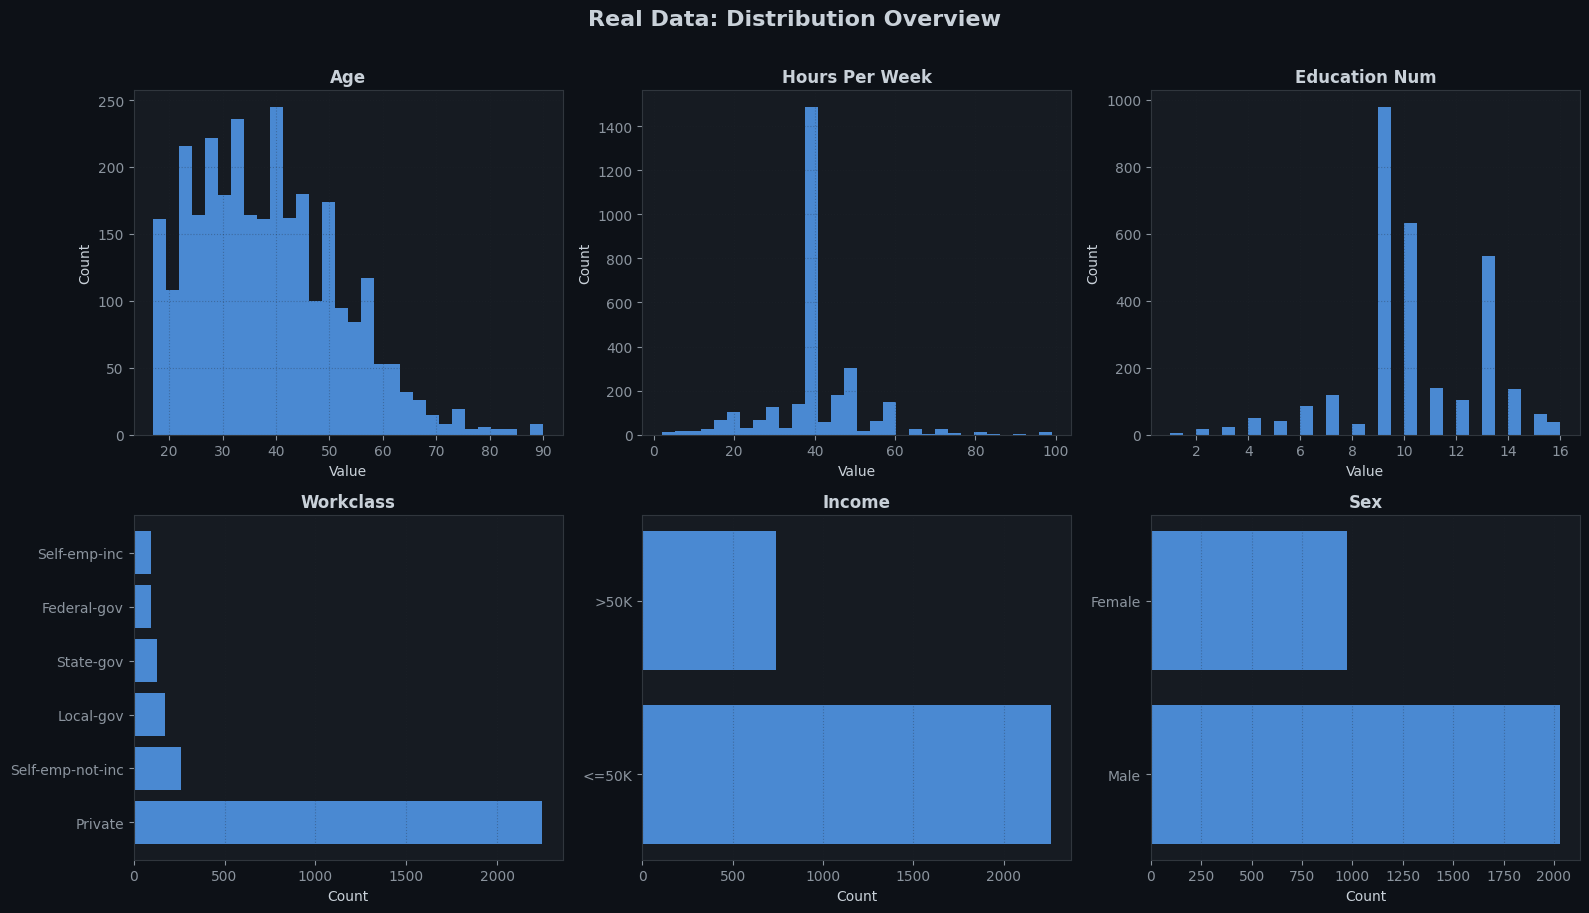

Real data overview saved.


In [11]:
# Visualize the real data distribution
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
fig.suptitle('Real Data: Distribution Overview', fontsize=16,
             fontweight='bold', color='#c9d1d9', y=1.01)

num_cols = ['age', 'hours.per.week', 'education.num']
cat_cols = ['workclass', 'income', 'sex']

for i, col in enumerate(num_cols):
    ax = axes[0, i]
    ax.hist(real_data[col].dropna(), bins=30,
            color=REAL_COLOR, alpha=0.8, edgecolor='none')
    ax.set_title(col.replace('.', ' ').title(), fontweight='bold')
    ax.set_xlabel('Value')
    ax.set_ylabel('Count')
    ax.grid(True, alpha=0.3)

for i, col in enumerate(cat_cols):
    ax = axes[1, i]
    vc = real_data[col].value_counts().head(6)
    bars = ax.barh(vc.index, vc.values,
                   color=REAL_COLOR, alpha=0.8)
    ax.set_title(col.replace('.', ' ').title(), fontweight='bold')
    ax.set_xlabel('Count')
    ax.grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.savefig('real_data_overview.png', dpi=150,
            bbox_inches='tight', facecolor='#0d1117')
plt.show()
print("Real data overview saved.")

---
## 3. Fit the Synthesizer and Generate Synthetic Data

In [12]:
# Auto-detect metadata
metadata = SingleTableMetadata()
metadata.detect_from_dataframe(real_data)

print("Metadata detected:")
print(f"  Columns: {len(metadata.columns)}")
for col, info in list(metadata.columns.items())[:5]:
    print(f"  {col}: {info['sdtype']}")
print("  ...")

Metadata detected:
  Columns: 15
  age: numerical
  workclass: categorical
  fnlwgt: numerical
  education: categorical
  education.num: numerical
  ...


In [13]:
# Fit the GaussianCopula synthesizer
print("Fitting GaussianCopulaSynthesizer...")

synth = GaussianCopulaSynthesizer(metadata)
synth.fit(real_data)

print("Fitting complete.")

Fitting GaussianCopulaSynthesizer...
Fitting complete.


In [14]:
# Sample synthetic data
print("Sampling 3000 synthetic records...")

synthetic_data = synth.sample(num_rows=3000)

print(f"Synthetic data shape: {synthetic_data.shape}")
print("\nFirst 3 synthetic records:")
print(synthetic_data.head(3))

Sampling 3000 synthetic records...
Synthetic data shape: (3000, 15)

First 3 synthetic records:
   age workclass  fnlwgt  education  education.num      marital.status  \
0   27   Private  139145    HS-grad             13  Married-civ-spouse   
1   34   Private  154399  Assoc-voc              8       Never-married   
2   37   Private  265619  Bachelors              7  Married-civ-spouse   

        occupation relationship   race     sex  capital.gain  capital.loss  \
0  Exec-managerial      Husband  White  Female          5265            11   
1   Prof-specialty      Husband  White    Male             0             0   
2   Prof-specialty    Unmarried  White    Male             3            32   

   hours.per.week native.country income  
0              68  United-States  <=50K  
1              58  United-States  <=50K  
2              25  United-States  <=50K  


---
## 4. Visual Comparison: Real vs Synthetic

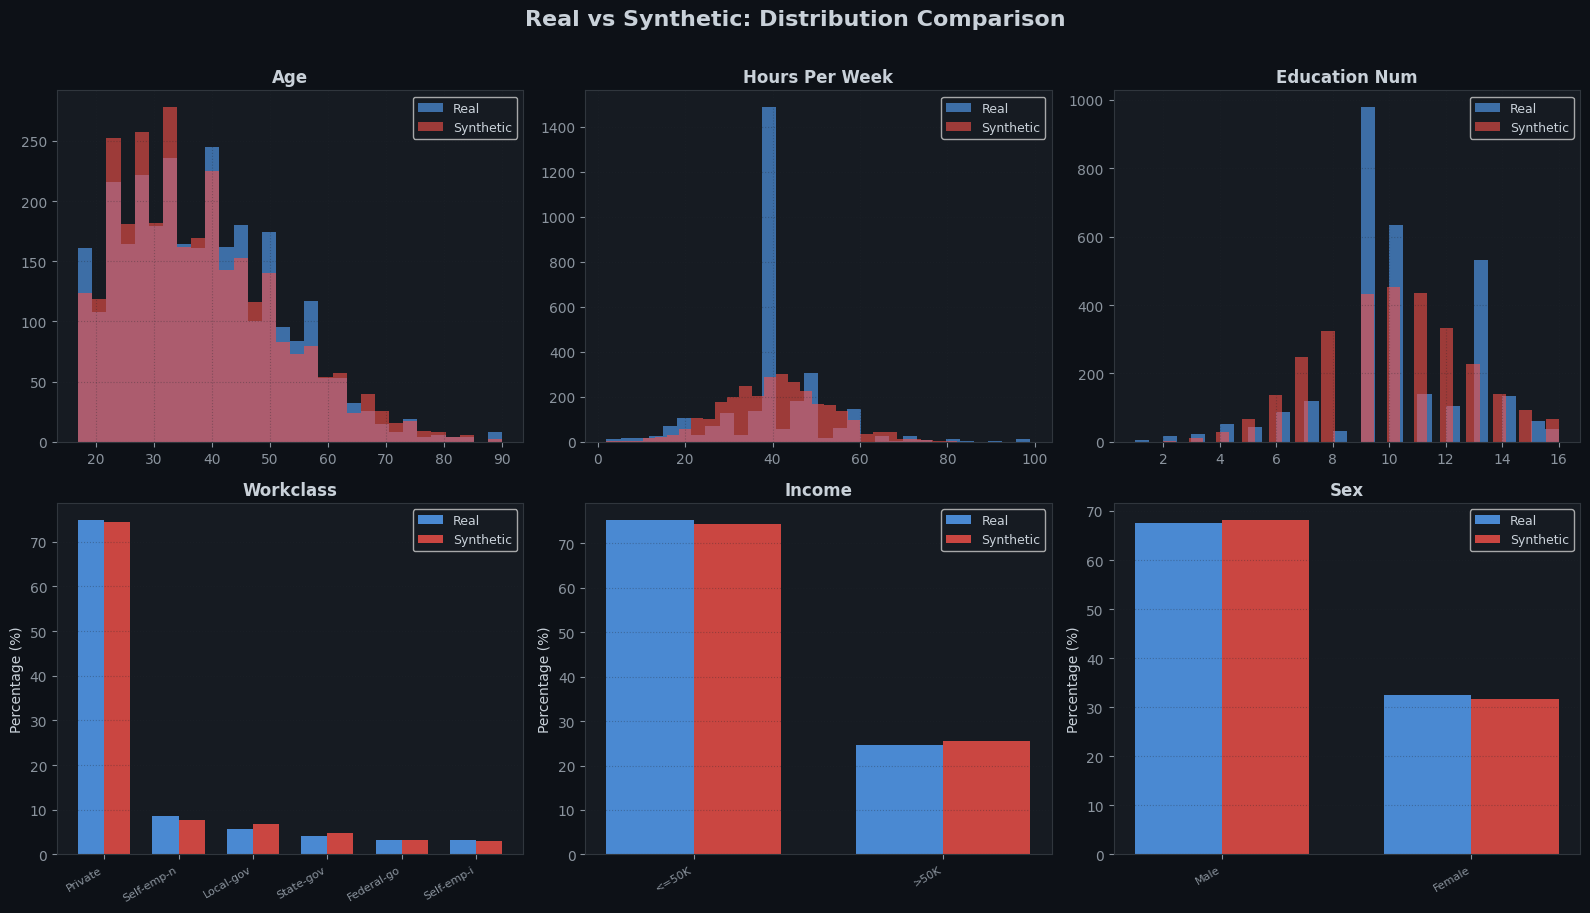

Comparison chart saved.


In [15]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
fig.suptitle('Real vs Synthetic: Distribution Comparison',
             fontsize=16, fontweight='bold',
             color='#c9d1d9', y=1.01)

compare_cols = ['age', 'hours.per.week', 'education.num']

for i, col in enumerate(compare_cols):
    ax = axes[0, i]
    ax.hist(real_data[col].dropna(), bins=30,
            color=REAL_COLOR, alpha=0.6,
            label='Real', edgecolor='none')
    ax.hist(synthetic_data[col].dropna(), bins=30,
            color=SYNTH_COLOR, alpha=0.6,
            label='Synthetic', edgecolor='none')
    ax.set_title(col.replace('.', ' ').title(), fontweight='bold')
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

cat_compare = ['workclass', 'income', 'sex']
for i, col in enumerate(cat_compare):
    ax = axes[1, i]
    cats = real_data[col].value_counts().index[:6]
    real_pct  = real_data[col].value_counts(normalize=True)[cats] * 100
    synth_pct = synthetic_data[col].value_counts(
                    normalize=True).reindex(cats, fill_value=0) * 100

    x = np.arange(len(cats))
    w = 0.35
    ax.bar(x - w/2, real_pct.values,  w,
           color=REAL_COLOR,  alpha=0.8, label='Real')
    ax.bar(x + w/2, synth_pct.values, w,
           color=SYNTH_COLOR, alpha=0.8, label='Synthetic')
    ax.set_xticks(x)
    ax.set_xticklabels(
        [str(c)[:10] for c in cats],
        rotation=30, ha='right', fontsize=8)
    ax.set_title(col.replace('.', ' ').title(), fontweight='bold')
    ax.set_ylabel('Percentage (%)')
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('real_vs_synthetic.png', dpi=150,
            bbox_inches='tight', facecolor='#0d1117')
plt.show()
print("Comparison chart saved.")

---
## 5. Correlation Preservation Check

Mean correlation difference: 0.0378
Below 0.10 is excellent. Below 0.15 is acceptable.


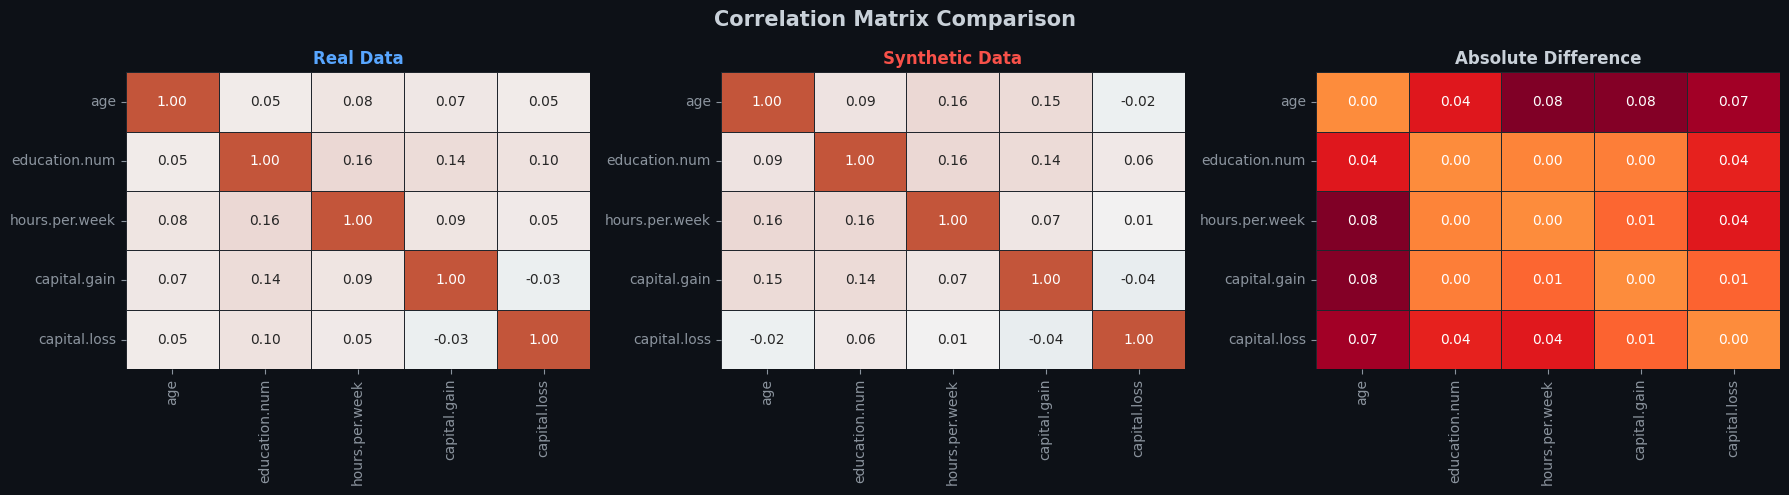

In [16]:
num_features = ['age', 'education.num', 'hours.per.week',
                'capital.gain', 'capital.loss']

real_corr  = real_data[num_features].corr()
synth_corr = synthetic_data[num_features].corr()

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Correlation Matrix Comparison',
             fontsize=15, fontweight='bold', color='#c9d1d9')

cmap = sns.diverging_palette(220, 20, as_cmap=True)

sns.heatmap(real_corr, ax=axes[0], cmap=cmap, center=0,
            annot=True, fmt='.2f', linewidths=0.5,
            linecolor='#21262d', cbar=False)
axes[0].set_title('Real Data', fontweight='bold', color='#58a6ff')

sns.heatmap(synth_corr, ax=axes[1], cmap=cmap, center=0,
            annot=True, fmt='.2f', linewidths=0.5,
            linecolor='#21262d', cbar=False)
axes[1].set_title('Synthetic Data', fontweight='bold', color='#f85149')

diff = (real_corr - synth_corr).abs()
sns.heatmap(diff, ax=axes[2], cmap='YlOrRd', center=0,
            annot=True, fmt='.2f', linewidths=0.5,
            linecolor='#21262d', cbar=False)
axes[2].set_title('Absolute Difference', fontweight='bold',
                  color='#c9d1d9')

mean_diff = diff.values[np.triu_indices_from(diff, k=1)].mean()
print(f"Mean correlation difference: {mean_diff:.4f}")
print("Below 0.10 is excellent. Below 0.15 is acceptable.")

plt.tight_layout()
plt.savefig('correlation_comparison.png', dpi=150,
            bbox_inches='tight', facecolor='#0d1117')
plt.show()

---
## 6. SDV Quality Report

In [17]:
print("Running SDV quality evaluation...")

quality_report = evaluate_quality(
    real_data, synthetic_data, metadata, verbose=False)

overall_score = quality_report.get_score()
print(f"\nOverall Quality Score: {overall_score:.4f}")
print("\nScore guide:")
print("  Above 0.90 = Excellent")
print("  0.85 to 0.90 = Good")
print("  Below 0.85 = Needs tuning")

details = quality_report.get_details(property_name='Column Shapes')
print("\nColumn Shapes (top 5):")
print(details.head())

Running SDV quality evaluation...

Overall Quality Score: 0.8155

Score guide:
  Above 0.90 = Excellent
  0.85 to 0.90 = Good
  Below 0.85 = Needs tuning

Column Shapes (top 5):
          Column        Metric     Score
0            age  KSComplement  0.961667
1      workclass  TVComplement  0.983000
2         fnlwgt  KSComplement  0.912667
3      education  TVComplement  0.959333
4  education.num  KSComplement  0.853667


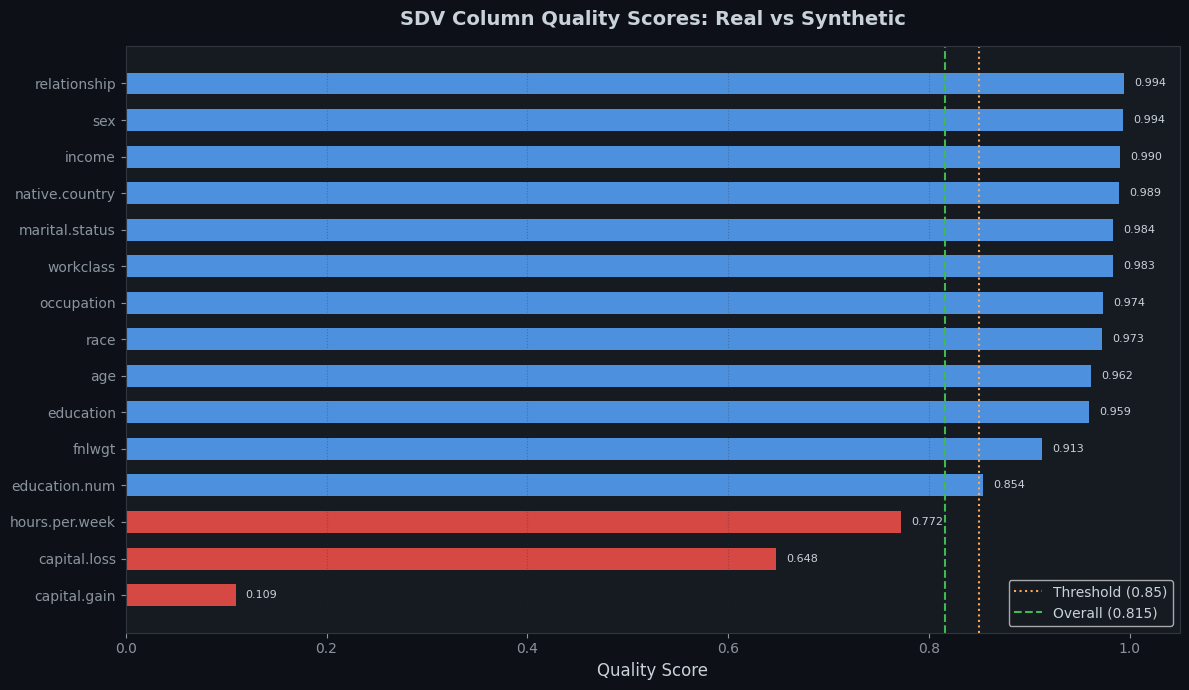

In [18]:
# Plot per-column quality scores
details_sorted = details.sort_values('Score', ascending=True)

fig, ax = plt.subplots(figsize=(12, 7))
fig.patch.set_facecolor('#0d1117')

colors = [SYNTH_COLOR if s < 0.85 else REAL_COLOR
          for s in details_sorted['Score']]

bars = ax.barh(details_sorted['Column'],
               details_sorted['Score'],
               color=colors, alpha=0.85, height=0.6)

ax.axvline(x=0.85, color='#ffa657', linestyle=':',
           linewidth=1.5, label='Threshold (0.85)')
ax.axvline(x=overall_score, color='#3fb950', linestyle='--',
           linewidth=1.5, label=f'Overall ({overall_score:.3f})')

ax.set_xlabel('Quality Score', fontsize=12)
ax.set_title('SDV Column Quality Scores: Real vs Synthetic',
             fontsize=14, fontweight='bold', pad=15)
ax.set_xlim(0, 1.05)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3, axis='x')

for bar, score in zip(bars, details_sorted['Score']):
    ax.text(score + 0.01, bar.get_y() + bar.get_height()/2,
            f'{score:.3f}', va='center', fontsize=8,
            color='#c9d1d9')

plt.tight_layout()
plt.savefig('sdv_quality_scores.png', dpi=150,
            bbox_inches='tight', facecolor='#0d1117')
plt.show()

---
## 7. TSTR: Train on Synthetic, Test on Real

This is the most important evaluation. We train a classifier on synthetic data
and test it on real held-out data. If the score is close to the real-trained
baseline, our synthetic data is genuinely useful for machine learning.

In [19]:
def prepare_features(df):
    d = df.copy()
    le = LabelEncoder()
    for col in d.select_dtypes('object').columns:
        d[col] = le.fit_transform(d[col].astype(str))
    return d

target = 'income'

real_enc  = prepare_features(real_data)
synth_enc = prepare_features(synthetic_data)

# Real train/test split
X_real  = real_enc.drop(columns=[target])
y_real  = real_enc[target]
X_tr_r, X_te_r, y_tr_r, y_te_r = train_test_split(
    X_real, y_real, test_size=0.2, random_state=42)

# Baseline: Train on Real, Test on Real
clf_real = GradientBoostingClassifier(n_estimators=100, random_state=42)
clf_real.fit(X_tr_r, y_tr_r)
f1_real = f1_score(y_te_r, clf_real.predict(X_te_r), average='weighted')

# TSTR: Train on Synthetic, Test on Real
X_synth = synth_enc.drop(columns=[target])
y_synth = synth_enc[target]
clf_synth = GradientBoostingClassifier(n_estimators=100, random_state=42)
clf_synth.fit(X_synth, y_synth)
f1_tstr = f1_score(y_te_r, clf_synth.predict(X_te_r), average='weighted')

tstr_ratio = f1_tstr / f1_real

print(f"Real-trained F1:      {f1_real:.4f}")
print(f"Synth-trained F1:     {f1_tstr:.4f}")
print(f"TSTR Ratio:           {tstr_ratio:.4f}")
print(f"\nInterpretation:")
if tstr_ratio >= 0.95:
    print("  Excellent. Synthetic data is highly useful for training.")
elif tstr_ratio >= 0.90:
    print("  Good. Synthetic data is useful with minor performance gap.")
else:
    print("  Needs improvement. Consider CTGAN for better fidelity.")

Real-trained F1:      0.8469
Synth-trained F1:     0.7062
TSTR Ratio:           0.8339

Interpretation:
  Needs improvement. Consider CTGAN for better fidelity.


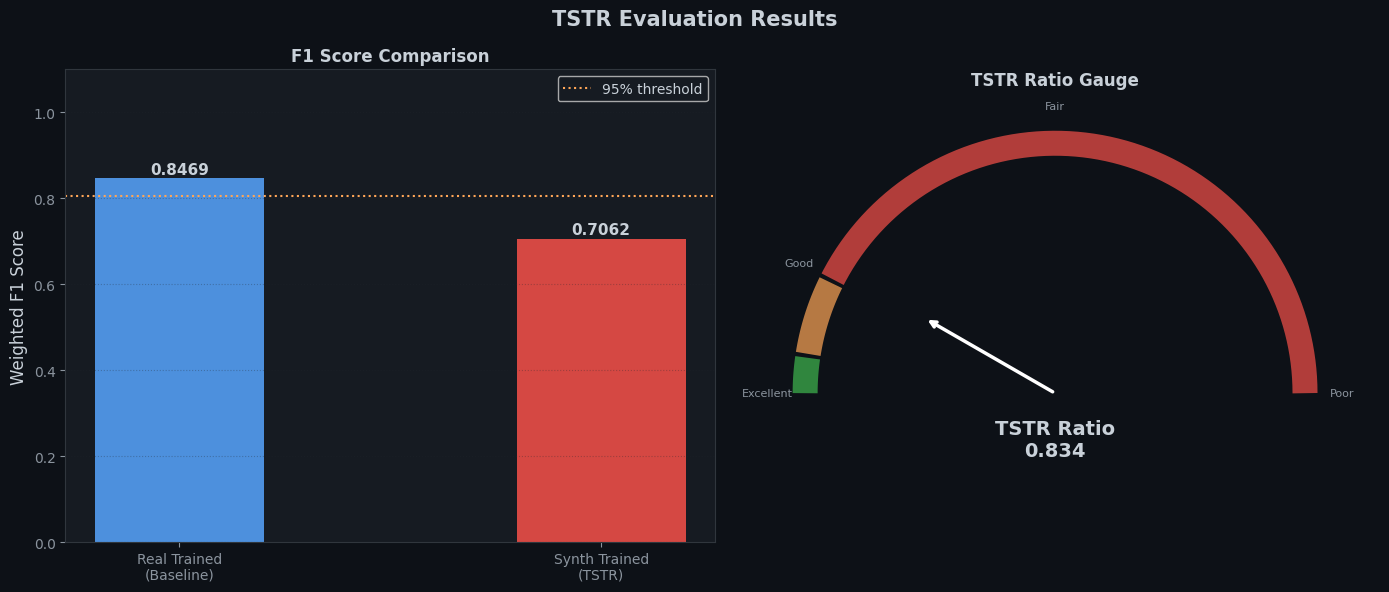

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('TSTR Evaluation Results',
             fontsize=15, fontweight='bold', color='#c9d1d9')

# Bar chart comparison
ax = axes[0]
labels = ['Real Trained\n(Baseline)', 'Synth Trained\n(TSTR)']
scores = [f1_real, f1_tstr]
bar_colors = [REAL_COLOR, SYNTH_COLOR]
bars = ax.bar(labels, scores, color=bar_colors, alpha=0.85, width=0.4)
ax.set_ylim(0, 1.1)
ax.set_ylabel('Weighted F1 Score', fontsize=12)
ax.set_title('F1 Score Comparison', fontweight='bold')
ax.axhline(y=0.95 * f1_real, color='#ffa657', linestyle=':',
           linewidth=1.5, label='95% threshold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3, axis='y')
for bar, score in zip(bars, scores):
    ax.text(bar.get_x() + bar.get_width()/2, score + 0.01,
            f'{score:.4f}', ha='center', fontweight='bold',
            fontsize=11, color='#c9d1d9')

# TSTR ratio gauge
ax2 = axes[1]
theta = np.linspace(0, np.pi, 200)
for i, (start, end, color) in enumerate([
    (0.0, 0.85, '#f85149'),
    (0.85, 0.95, '#ffa657'),
    (0.95, 1.0, '#3fb950')
]):
    mask = (theta >= start * np.pi) & (theta <= end * np.pi)
    ax2.plot(np.cos(theta[mask]), np.sin(theta[mask]),
             linewidth=18, color=color, solid_capstyle='butt', alpha=0.7)

needle_angle = tstr_ratio * np.pi
ax2.annotate('', xy=(0.6 * np.cos(needle_angle),
                     0.6 * np.sin(needle_angle)),
             xytext=(0, 0),
             arrowprops=dict(arrowstyle='->', color='white',
                             lw=2.5))
ax2.text(0, -0.25, f'TSTR Ratio\n{tstr_ratio:.3f}',
         ha='center', fontsize=14, fontweight='bold',
         color='#c9d1d9')
ax2.set_xlim(-1.3, 1.3)
ax2.set_ylim(-0.5, 1.2)
ax2.set_aspect('equal')
ax2.axis('off')
ax2.set_title('TSTR Ratio Gauge', fontweight='bold')
for val, label in [(0, 'Poor'), (0.5, 'Fair'),
                    (0.85, 'Good'), (1.0, 'Excellent')]:
    a = val * np.pi
    ax2.text(1.15 * np.cos(a), 1.15 * np.sin(a),
             label, ha='center', va='center',
             fontsize=8, color='#8b949e')

plt.tight_layout()
plt.savefig('tstr_results.png', dpi=150,
            bbox_inches='tight', facecolor='#0d1117')
plt.show()

---
## 8. Summary

In [21]:
print("=" * 55)
print("  TMD-01: Tabular Quickstart · Summary")
print("=" * 55)
print(f"  Real records used:          {len(real_data):,}")
print(f"  Synthetic records generated: {len(synthetic_data):,}")
print(f"  SDV Quality Score:           {overall_score:.4f}")
print(f"  Mean Correlation Diff:       {mean_diff:.4f}")
print(f"  Real-trained F1:             {f1_real:.4f}")
print(f"  TSTR F1:                     {f1_tstr:.4f}")
print(f"  TSTR Ratio:                  {tstr_ratio:.4f}")
print("=" * 55)
print()
print("Next steps:")
print("  TMD-02: CTGAN for imbalanced fraud detection")
print("  TMD-03: Synthetic text generation with LLMs")
print()
print("Handbook: Teaching Machines to Dream")
print("Authors:  Aimal Khan · Hamza Raziq Khan")

  TMD-01: Tabular Quickstart · Summary
  Real records used:          3,000
  Synthetic records generated: 3,000
  SDV Quality Score:           0.8155
  Mean Correlation Diff:       0.0378
  Real-trained F1:             0.8469
  TSTR F1:                     0.7062
  TSTR Ratio:                  0.8339

Next steps:
  TMD-02: CTGAN for imbalanced fraud detection
  TMD-03: Synthetic text generation with LLMs

Handbook: Teaching Machines to Dream
Authors:  Aimal Khan · Hamza Raziq Khan


---

## What We Covered

1. Loaded and explored a real tabular dataset
2. Fitted a GaussianCopula synthesizer using SDV
3. Generated 3,000 synthetic records
4. Visually compared real vs synthetic distributions
5. Checked correlation matrix preservation
6. Ran the SDV built-in quality report
7. Performed a full TSTR evaluation with a gauge chart

### Key Takeaway

GaussianCopula is the fastest way to get synthetic tabular data that is statistically
faithful to the original. When TSTR ratio is above 0.95 your synthetic data is ready
to use in downstream ML workflows.

For imbalanced datasets or complex multi-modal distributions, move to CTGAN covered
in the next notebook.

---

*Part of the Teaching Machines to Dream handbook series.*  
*Aimal Khan · Hamza Raziq Khan · Peshawar, 2025*